# Exploratory Data Analysis — Scraped Product Data

Run `python main.py` from the project root first so that `output/products_clean.csv` exists.

In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt

# Load the generated clothing dataset
df = pd.read_csv('../data/clothing_products.csv')
df.head()

,product_id,name,price,rating,availability,category,brand,description,product_url,image_url
0,1,Blue Top,500.0,4.5,In Stock,General,Unbranded,Blue Top in brand Unbranded,https://automationexercise.com/product_details/1,https://automationexercise.com/get_product_pic...
1,2,Men Tshirt,400.0,4.5,In Stock,General,Unbranded,Men Tshirt in brand Unbranded,https://automationexercise.com/product_details/2,https://automationexercise.com/get_product_pic...
2,3,Sleeveless Dress,1000.0,4.5,In Stock,General,Unbranded,Sleeveless Dress in brand Unbranded,https://automationexercise.com/product_details/3,https://automationexercise.com/get_product_pic...
3,4,Stylish Dress,1500.0,4.5,In Stock,General,Unbranded,Stylish Dress in brand Unbranded,https://automationexercise.com/product_details/4,https://automationexercise.com/get_product_pic...
4,5,Winter Top,600.0,4.5,In Stock,General,Unbranded,Winter Top in brand Unbranded,https://automationexercise.com/product_details/5,https://automationexercise.com/get_product_pic...


In [2]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    34 non-null     int64  
 1   name          34 non-null     str    
 2   price         34 non-null     float64
 3   rating        34 non-null     float64
 4   availability  34 non-null     str    
 5   category      34 non-null     str    
 6   brand         34 non-null     str    
 7   description   34 non-null     str    
 8   product_url   34 non-null     str    
 9   image_url     34 non-null     str    
dtypes: float64(2), int64(1), str(7)
memory usage: 2.8 KB


,product_id,name,price,rating,availability,category,brand,description,product_url,image_url
count,34.000000,34,34.000000,34.0,34,34,34,34,34,34
unique,NaN,34,NaN,NaN,1,1,1,34,34,34
top,NaN,Blue Top,NaN,NaN,In Stock,General,Unbranded,Blue Top in brand Unbranded,https://automationexercise.com/product_details/1,https://automationexercise.com/get_product_pic...
freq,NaN,1,NaN,NaN,34,34,34,1,1,1
mean,21.470588,NaN,1231.294118,4.5,NaN,NaN,NaN,NaN,NaN,NaN
std,13.239599,NaN,973.667591,0.0,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,278.000000,4.5,NaN,NaN,NaN,NaN,NaN,NaN
25%,11.250000,NaN,619.750000,4.5,NaN,NaN,NaN,NaN,NaN,NaN
50%,20.500000,NaN,1025.000000,4.5,NaN,NaN,NaN,NaN,NaN,NaN
75%,32.500000,NaN,1400.000000,4.5,NaN,NaN,NaN,NaN,NaN,NaN


## Summary statistics

In [3]:
print('Total products:', len(df))
print('Average price:', round(df['price'].mean(), 2))
print('Min price:', df['price'].min())
print('Max price:', df['price'].max())
print('Most common rating:', df['rating'].mode().iloc[0])
print('Available products:', df['availability'].str.contains('In stock', case=False, na=False).sum())

Total products: 34
Average price: 1231.29
Min price: 278.0
Max price: 5000.0
Most common rating: 4.5
Available products: 34


## Top rated and lowest priced products

In [4]:
# Highest rated products
df.nlargest(10, 'rating')[['name', 'rating', 'price']]

,name,rating,price
0,Blue Top,4.5,500.0
1,Men Tshirt,4.5,400.0
2,Sleeveless Dress,4.5,1000.0
3,Stylish Dress,4.5,1500.0
4,Winter Top,4.5,600.0
5,Summer White Top,4.5,400.0
6,Madame Top For Women,4.5,1000.0
7,Fancy Green Top,4.5,700.0
8,Sleeves Printed Top - White,4.5,499.0
9,Half Sleeves Top Schiffli Detailing - Pink,4.5,359.0


In [5]:
# Lowest priced products
df.nsmallest(10, 'price')[['name', 'price']]

,name,price
10,Frozen Tops For Kids,278.0
12,Printed Off Shoulder Top - White,315.0
9,Half Sleeves Top Schiffli Detailing - Pink,359.0
1,Men Tshirt,400.0
5,Summer White Top,400.0
13,Sleeves Top and Short - Blue & Pink,478.0
8,Sleeves Printed Top - White,499.0
0,Blue Top,500.0
4,Winter Top,600.0
11,Full Sleeves Top Cherry - Pink,679.0


## Quick visual checks

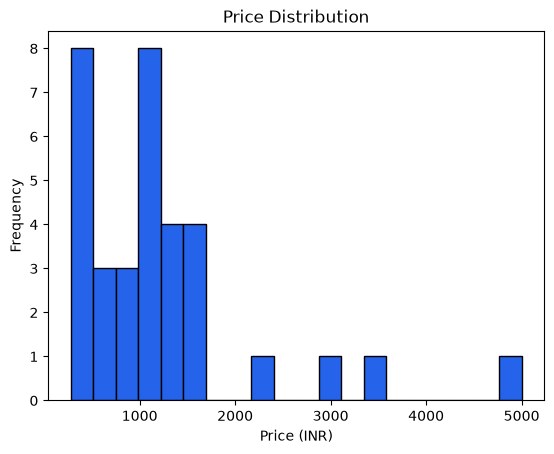

In [6]:
df['price'].plot(kind='hist', bins=20, title='Price Distribution', color='#2563eb', edgecolor='black')
plt.xlabel('Price (INR)')
plt.show()

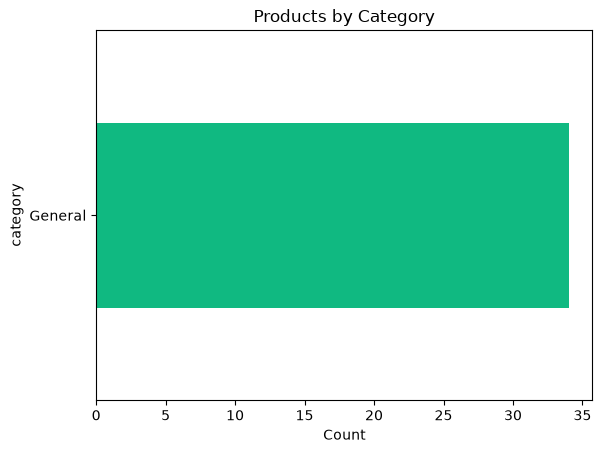

In [7]:
df['category'].value_counts().head(15).plot(kind='barh', title='Products by Category', color='#10b981')
plt.gca().invert_yaxis()
plt.xlabel('Count')
plt.show()